In [1]:
# Import libraries

import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Load required datasets

customers = pd.read_csv(
    "../data/olist_customers_dataset.csv"
)

orders = pd.read_csv(
    "../data/cleaned/orders_clean.csv"
)

print("Data Loaded Successfully")

Data Loaded Successfully


In [3]:
# Combine customer and order data

customer_orders = orders.merge(
    customers,
    on="customer_id",
    how="left"
)

customer_orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,purchase_year,purchase_month,month_name,delivery_days,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017,10,October,8.0,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2018,7,July,13.0,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,2018,8,August,9.0,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,2017,11,November,13.0,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2018,2,February,2.0,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP


In [4]:
# Count orders by state

state_orders = (
    customer_orders
    .groupby("customer_state")["order_id"]
    .count()
    .sort_values(ascending=False)
)

state_orders.head(10)

customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
SC     3637
BA     3380
DF     2140
ES     2033
GO     2020
Name: order_id, dtype: int64

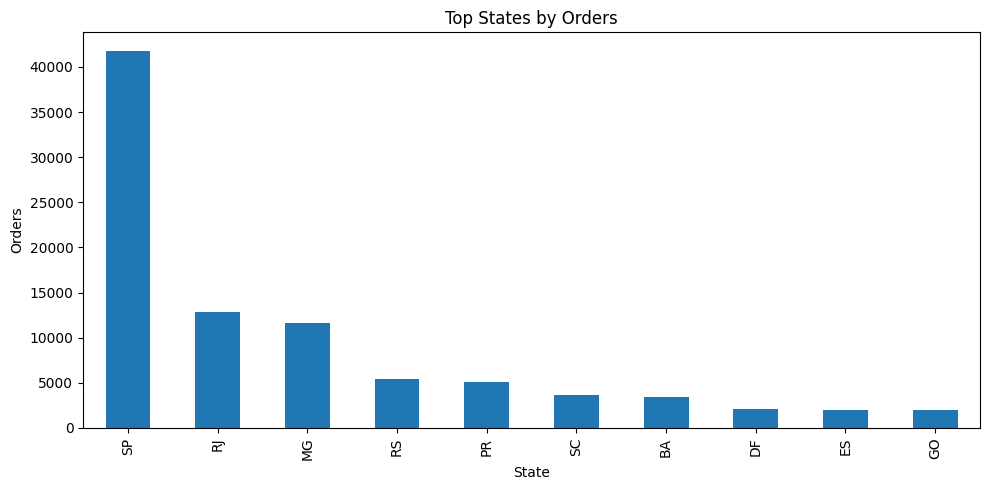

In [5]:
# Plot top states

state_orders.head(10).plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Top States by Orders")
plt.xlabel("State")
plt.ylabel("Orders")

plt.tight_layout()

plt.show()

SP (São Paulo) is the primary market for the business, contributing significantly more orders than any other state.

RJ and MG form the second tier of customer demand.

Marketing campaigns, inventory planning, and seller expansion efforts should prioritize SP due to its high transaction volume.

In [6]:
# Count orders by city

city_orders = (
    customer_orders
    .groupby("customer_city")["order_id"]
    .count()
    .sort_values(ascending=False)
)

city_orders.head(10)

customer_city
sao paulo                15540
rio de janeiro            6882
belo horizonte            2773
brasilia                  2131
curitiba                  1521
campinas                  1444
porto alegre              1379
salvador                  1245
guarulhos                 1189
sao bernardo do campo      938
Name: order_id, dtype: int64

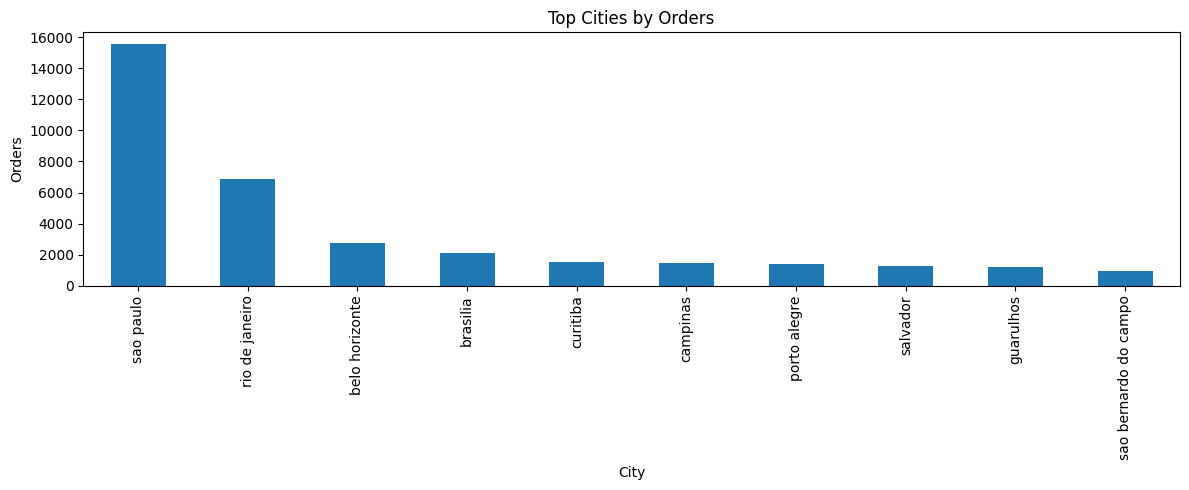

In [7]:
# Plot top cities

city_orders.head(10).plot(
    kind="bar",
    figsize=(12,5)
)

plt.title("Top Cities by Orders")
plt.xlabel("City")
plt.ylabel("Orders")

plt.tight_layout()

plt.show()

In [8]:
# Count customers by state

state_customers = (
    customers
    .groupby("customer_state")["customer_unique_id"]
    .nunique()
    .sort_values(ascending=False)
)

state_customers.head(10)

customer_state
SP    40302
RJ    12384
MG    11259
RS     5277
PR     4882
SC     3534
BA     3277
DF     2075
ES     1964
GO     1952
Name: customer_unique_id, dtype: int64

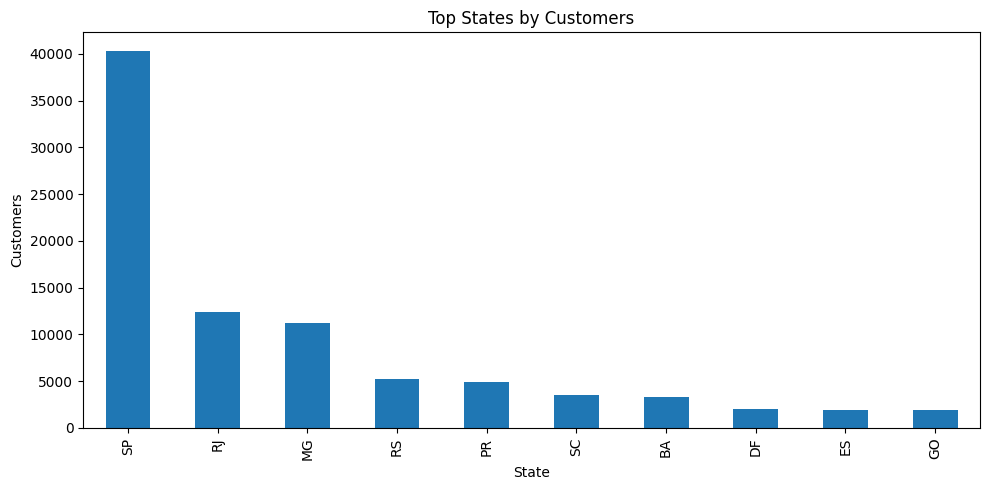

In [9]:
# Plot customer distribution

state_customers.head(10).plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Top States by Customers")
plt.xlabel("State")
plt.ylabel("Customers")

plt.tight_layout()

plt.show()

In [10]:
# Load payments

payments = pd.read_csv(
    "../data/olist_order_payments_dataset.csv"
)

In [11]:
# Count payment methods

payment_methods = (
    payments["payment_type"]
    .value_counts()
)

payment_methods

payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64

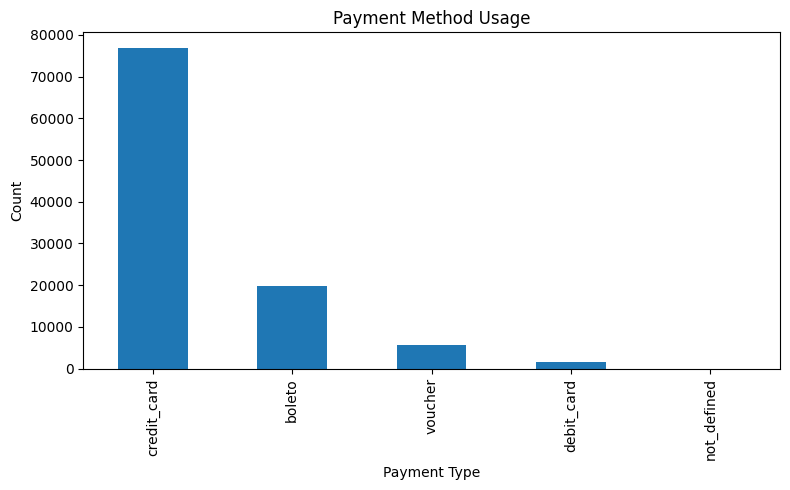

In [12]:
# Plot payment methods

payment_methods.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Payment Method Usage")
plt.xlabel("Payment Type")
plt.ylabel("Count")

plt.tight_layout()

plt.show()

Credit cards are the preferred payment method by a large margin.

Boleto remains an important alternative payment channel.

Debit card usage is relatively low, indicating customer preference for installment-based or credit transactions.